# Credit Risk Scoring via Logistic Regression

In this project, we will understand Logistic Regression by modelling good/bad credit risk customers using German Credit Dataset.

Can we predict risky borrowers? How to handle class imbalance? Why minority detection is difficult? Which financial behaviors correlate with good/bad credit?

##Step 1. Data Loading

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jumpingdino/german-credit-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'german-credit-dataset' dataset.
Path to dataset files: /kaggle/input/german-credit-dataset


In [5]:
# List files in the downloaded dataset directory
file_names = os.listdir(path)
print("Files in dataset directory:", file_names)

# Assuming the main data file is 'german_credit_data.csv'
# We'll construct the full path to the CSV file.
csv_file_path = os.path.join(path, 'german_credit_data.csv')

Files in dataset directory: ['german_credit_data.csv']


##Step 2. EDA

In [6]:
# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [7]:
# Categorical Features Description
df.describe(include='object')

,status_account,credit_history,purpose,status_savings,years_employment,status_and_sex,secondary_obligor,collateral,other_installment_plans,housing,job,telephone,is_foreign_worker,target
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2,2
top,no checking account,existing credits paid back duly till now,radio/television,< 100 DM,1 to < 4 years,male : single,none,real estate,none,own,skilled employee/ official,none,yes,good
freq,394,530,280,603,339,548,907,332,814,713,630,596,963,700


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [9]:
df.shape

(1000, 21)

In [10]:
df['target'].value_counts()

,count
target,
good,700
bad,300


<Axes: xlabel='target', ylabel='count'>

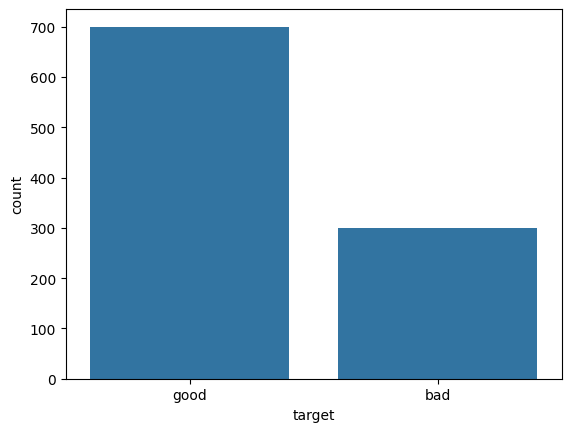

In [11]:
import seaborn as sns
sns.countplot(x='target', data=df)

Summary:


*   The German Credit Dataset was loaded from KaggleHub. It contains 1000 rows, 21 features.
*   There are 7 numerical columns and 21 categorical columns and no missing values.
The target variable shows Good vs Bad credit application risk.

*   The ratio between the two classes is 70:30 as there are 700 data points in Good class vs 300 data points in Bad class. This indicates class imbalance.



In [12]:
#Seperating numerical and categorical data for analysis
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

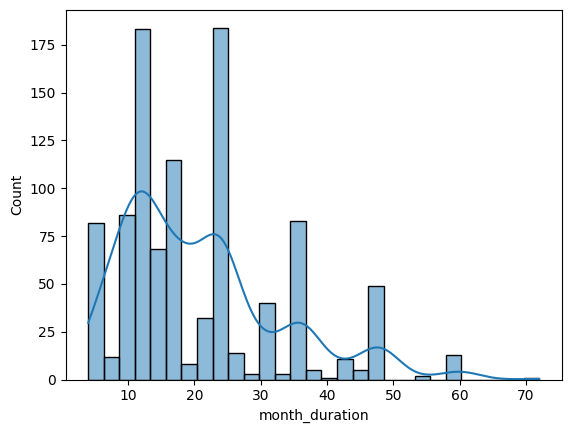

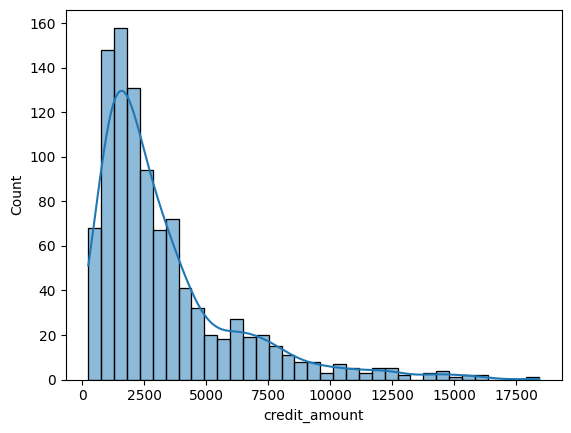

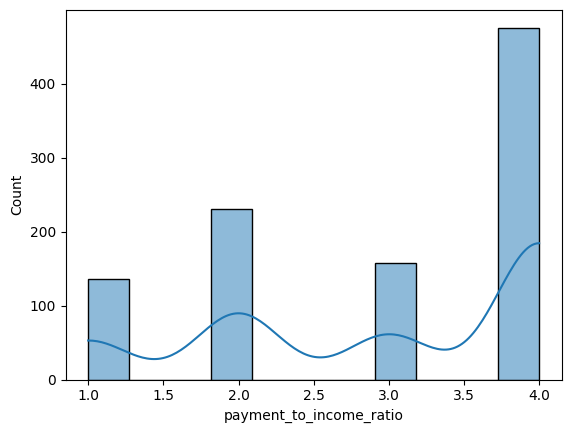

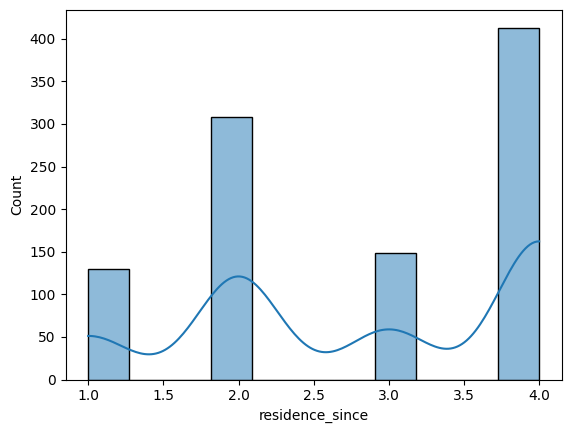

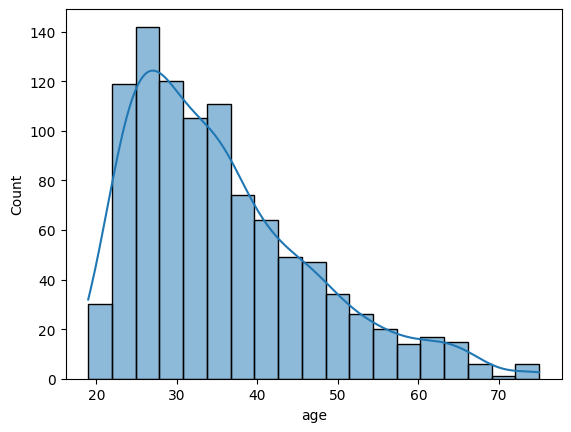

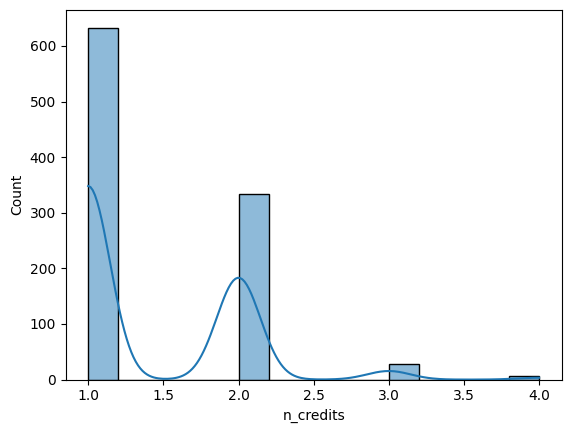

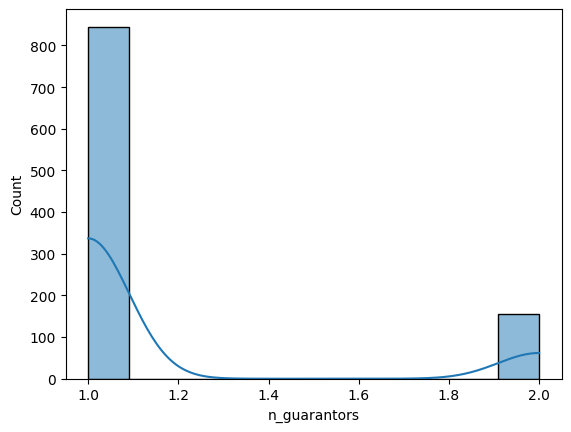

In [13]:
#Numerical Data
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

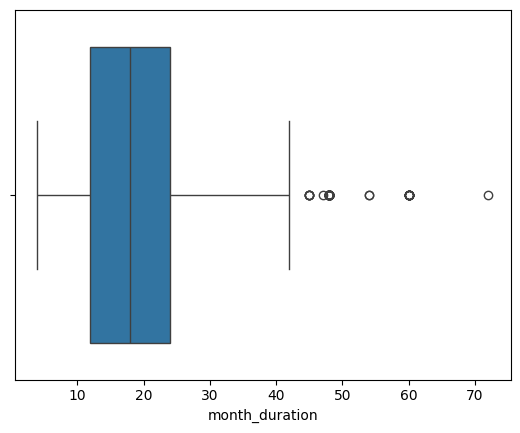

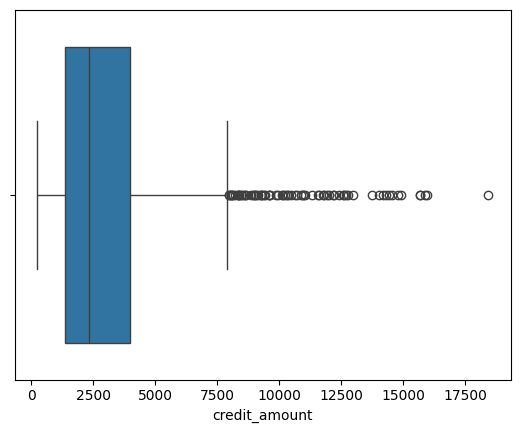

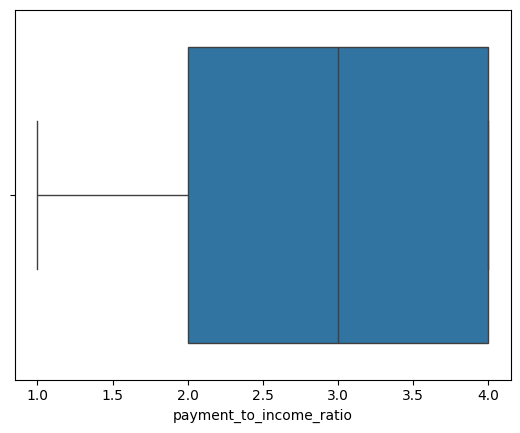

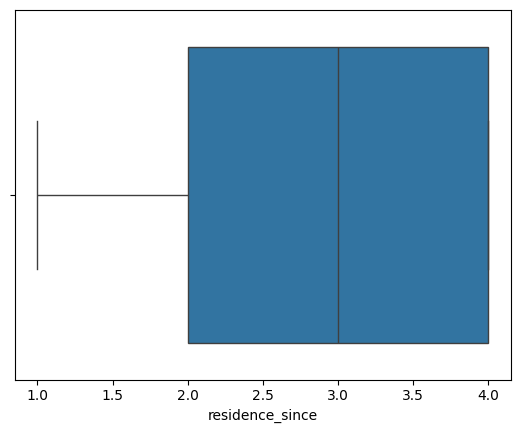

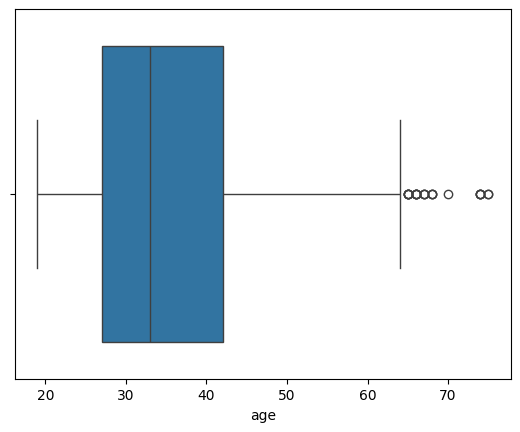

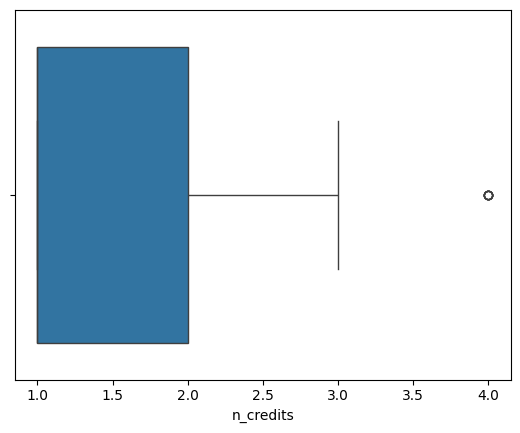

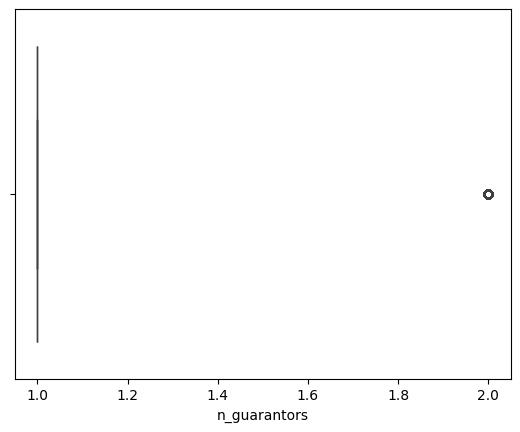

In [14]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

Text(0.5, 1.0, 'Distribution of Credit Amount')

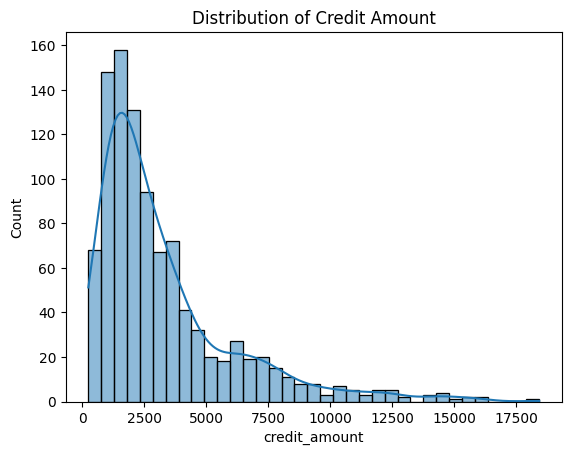

In [15]:
sns.histplot(df['credit_amount'], kde=True)
plt.title('Distribution of Credit Amount')

Text(0.5, 1.0, 'Credit Amount Distribution by Target')

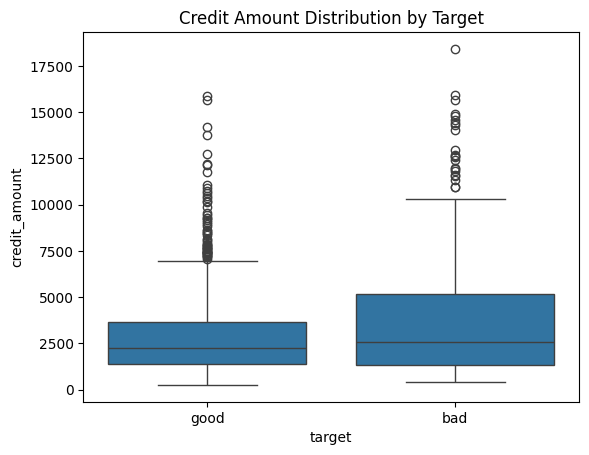

In [16]:
sns.boxplot(x='target', y='credit_amount', data=df)
plt.title('Credit Amount Distribution by Target')

Text(0.5, 1.0, 'Housing Distribution by Target')

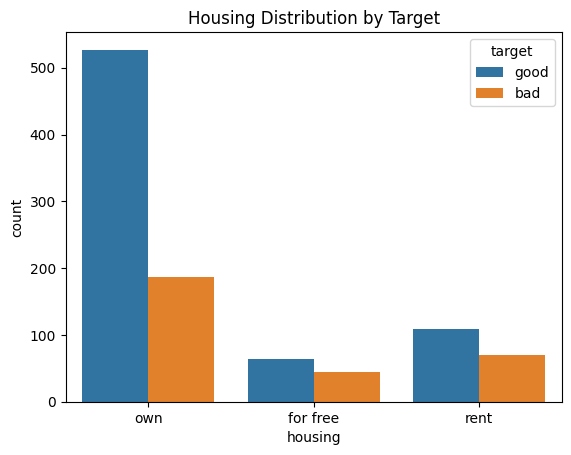

In [17]:
sns.countplot(x='housing', hue='target', data=df)
plt.title('Housing Distribution by Target')

Text(0.5, 1.0, 'Correlation Map')

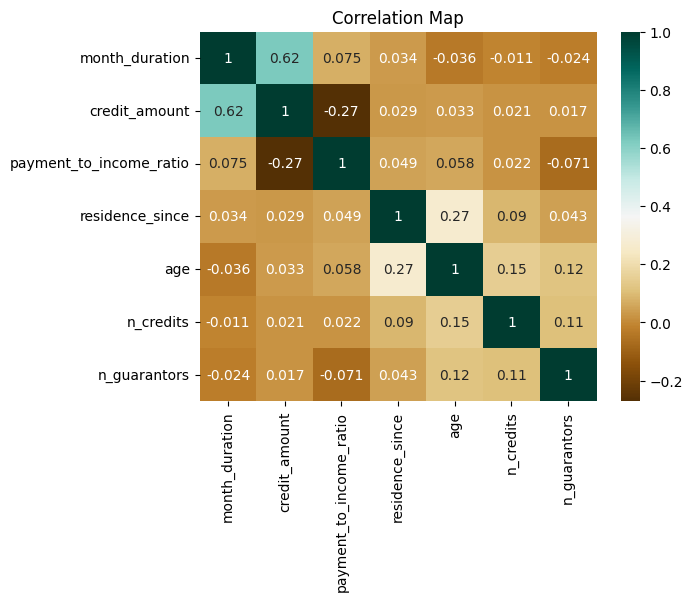

In [18]:
##Correlation Map

sns.heatmap(df[num_cols].corr(), annot=True, cmap='BrBG')
plt.title('Correlation Map')

###Summary:

*   Credit amount feature is heavily right-skewed with high value outliers so log transformation cab be applied.
*   Month duration and credit amount are highly correlated, gives redundant information.
*   Majority of the customers have own housing
*   "Status_and_sex" and "is_foreign_worker" are sensitive features in the dataset that I can use to perform ethical analysis.




## Step 3: Data Cleaning & Preprocessing

<Axes: xlabel='credit_amount', ylabel='Count'>

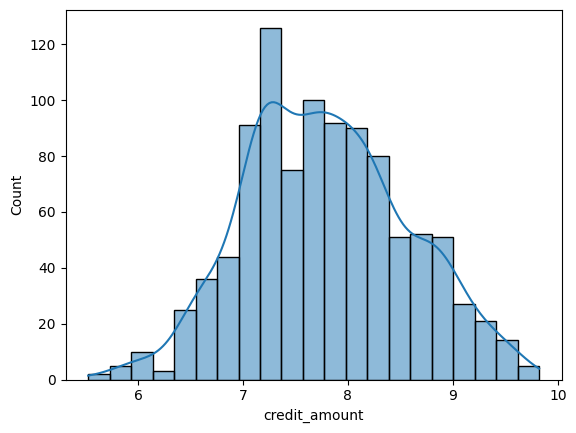

In [19]:
#Log Transforming Credit Amount
df['credit_amount'] = np.log1p(df['credit_amount'])

sns.histplot(df['credit_amount'], kde=True)

The credit_amount feature exhibited significant right skewness with numerous high-value statistical outliers. Since these observations likely represent legitimate financial behavior rather than noise, they were retained for analysis.

In [20]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [21]:
df_encoded.head()
#target_good: good - true (1), bad - false (0)

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,status_account_< 0 DM,status_account_>= 200 DM,status_account_no checking account,...,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes,target_good
0,6,7.064759,4,4,67,2,1,True,False,False,...,True,False,True,False,True,False,False,True,True,True
1,48,8.691483,2,2,22,1,1,False,False,False,...,True,False,True,False,True,False,False,False,True,False
2,12,7.648263,2,3,49,1,2,False,False,True,...,True,False,True,False,False,False,True,False,True,True
3,42,8.972464,2,4,45,1,2,True,False,False,...,True,False,False,False,True,False,False,False,True,True
4,24,8.491055,3,4,53,2,2,True,False,False,...,True,False,False,False,True,False,False,False,True,False


In [22]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   month_duration                                                              1000 non-null   int64  
 1   credit_amount                                                               1000 non-null   float64
 2   payment_to_income_ratio                                                     1000 non-null   int64  
 3   residence_since                                                             1000 non-null   int64  
 4   age                                                                         1000 non-null   int64  
 5   n_credits                                                                   1000 non-null   int64  
 6   n_guarantors                                     

In [23]:
df_encoded.columns

Index(['month_duration', 'credit_amount', 'payment_to_income_ratio',
       'residence_since', 'age', 'n_credits', 'n_guarantors',
       'status_account_< 0 DM', 'status_account_>= 200 DM',
       'status_account_no checking account',
       'credit_history_critical account/ other credits existing (not at this bank)',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/ all credits paid back duly',
       'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_others',
       'purpose_radio/television', 'purpose_repairs', 'purpose_retraining',
       'status_savings_500 to < 1000 DM', 'status_savings_< 100 DM',
       'status_savings_>= 1000 DM',
       'status_savings_unknown/ no savings account',
       'years_employment_4 to < 7 years', 'years_employment_< 1 year',
       'years_em

In [24]:
df_encoded.shape

(1000, 49)

##Summary:


*   Performed log-transform on "credit_amount" to reduce right-skew distribution
*   Encoded all the categorical features using one-hot encoding




##Step 5. Model Building - Baseline Model

In [25]:
X = df_encoded.drop('target_good', axis=1)
y = df_encoded['target_good']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])  # transform only, not fit

In [27]:
#Baseline Model before handling Class Imbalance
lr = LogisticRegression(solver='liblinear',max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [28]:
y_prob = lr.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.48      0.43      0.46        60
        True       0.77      0.80      0.78       140

    accuracy                           0.69       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.68      0.69      0.69       200



In [30]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.7526190476190475)

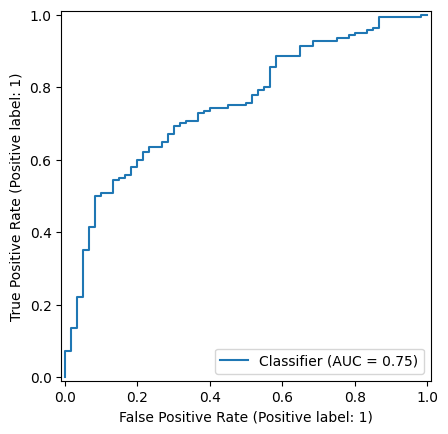

In [31]:
#ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [32]:
#Coeffecients Analysis for Interpretability
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coefficients.sort_values(by='Coefficient')

,Feature,Coefficient
47,is_foreign_worker_yes,-0.858784
14,purpose_car (new),-0.779531
17,purpose_education,-0.775156
38,collateral_savings agreement/life insurance,-0.540255
24,status_savings_< 100 DM,-0.533443
42,housing_rent,-0.530482
21,purpose_repairs,-0.453839
44,job_unemployed/ unskilled - non-resident,-0.446343
0,month_duration,-0.422794
7,status_account_< 0 DM,-0.364661


##Results Interpretation


-   Minority class has performance metrics in between 40-50% while having 77-79% accuracy for Majority class. Clearly the model struggles to perform well on the minority class.
-   This is expected because of the 70:30 class imbalance in the dataset.
-    With only 43% recall on False/Bad class, the model will miss more than half of all risky applicants.
-    AUC of 0.75 means the model has meaningful ability to predict without much tuning, for a linear model.




##Step 6. Model Enhancement - Handling Class Imbalance via SMOTE

In [33]:
##HANDLE CLASS IMBALANCE VIA SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [34]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
target_good
True     560
False    240
Name: count, dtype: int64

After SMOTE:
target_good
True     560
False    560
Name: count, dtype: int64


In [35]:
lr_smote = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_train_smote, y_train_smote)


LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [36]:
y_pred_smote = lr_smote.predict(X_test)

y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]


In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


Classification Report:
              precision    recall  f1-score   support

       False       0.45      0.48      0.46        60
        True       0.77      0.74      0.76       140

    accuracy                           0.67       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.67      0.67      0.67       200



In [38]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))


Confusion Matrix:
[[ 29  31]
 [ 36 104]]


In [39]:
print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_smote))


ROC-AUC Score:
0.6988095238095238


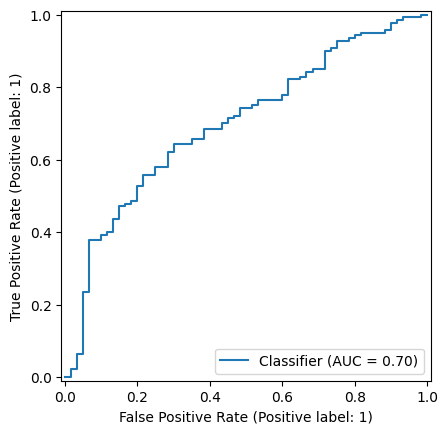

In [40]:
#ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_smote)

In [41]:
#Coeffecients Analysis for Interpretability
coefficients_smote = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_smote.coef_[0]
})

coefficients_smote.sort_values(by='Coefficient')

,Feature,Coefficient
14,purpose_car (new),-1.859250
17,purpose_education,-1.694552
21,purpose_repairs,-1.326274
38,collateral_savings agreement/life insurance,-1.259896
13,credit_history_no credits taken/ all credits p...,-1.229434
19,purpose_others,-1.198427
45,job_unskilled - resident,-1.067380
42,housing_rent,-1.019990
43,job_skilled employee/ official,-1.006910
30,years_employment_unemployed,-0.967103


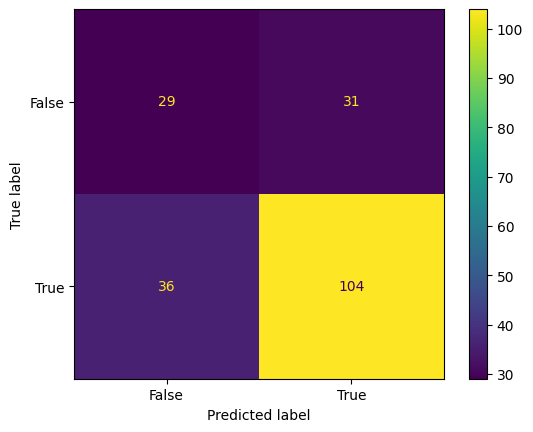

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)

## Summary:


SMOTE balanced the training set from 560/240 to **560/560** by synthetically
generating minority class samples.

| Metric | Baseline | After SMOTE | Change |
|---|---|---|---|
| Bad Recall | 0.43 | 0.50 | +0.07 |
| Good Recall | 0.79 | 0.75 | -0.04 |
| Accuracy | 0.69 | 0.68 | -0.01 |

SMOTE slightly improved bad credit recall (+7%) but at the cost of overall accuracy.

There is no substantial improvement because the core limitation is
logistic regression's **linear decision boundary** -  it cannot capture the complex
interactions between dataset features that distinguish risky borrowers.

Comparing coefficients before and after SMOTE reveals how class balancing
affects what the model learns to rely on:

| Feature | Baseline | Post-SMOTE |
|---|---|---|
| is_foreign_worker_yes | -0.857 | -0.386 |
| purpose_car (new) | -0.780 | -1.862 |
| purpose_education | -0.772 | -1.693 |

**Positive finding:** SMOTE nearly halved the `is_foreign_worker` coefficient
(-0.857 → -0.386), suggesting that class balancing reduced the model's reliance
on nationality as a risk signal. This is a rare case where a technical fix had
a measurable fairness benefit. However, SMOTE significantly increased loan purpose penalties,
particularly for car loans and education loans. Whether this reflects genuine
financial risk or historical lending bias against borrowers who take these loan
types warrants further investigation.                                 

##Step 6: Model Interpretation and Ethics Analysis

In [43]:
# Who is the model failing on?
X_test_analysis = X_test.copy()
X_test_analysis['true'] = y_test.values
X_test_analysis['predicted'] = y_pred
X_test_analysis['correct'] = X_test_analysis['true'] == X_test_analysis['predicted']

# Error rate among foreign workers vs non-foreign workers
print("Error Analysis by Foreign Worker Status:")
print(X_test_analysis.groupby('is_foreign_worker_yes')['correct'].mean())

Error Analysis by Foreign Worker Status:
is_foreign_worker_yes
False    0.888889
True     0.680628
Name: correct, dtype: float64


In [44]:
# Error Analysis by Foreign Worker Status - POST SMOTE MODEL
X_test_analysis_smote = X_test.copy()
X_test_analysis_smote['true'] = y_test.values
X_test_analysis_smote['predicted'] = y_pred_smote  # smote model predictions
X_test_analysis_smote['correct'] = X_test_analysis_smote['true'] == X_test_analysis_smote['predicted']

print("Error Analysis by Foreign Worker Status (Post-SMOTE):")
print(X_test_analysis_smote.groupby('is_foreign_worker_yes')['correct'].mean())

Error Analysis by Foreign Worker Status (Post-SMOTE):
is_foreign_worker_yes
False    0.888889
True     0.654450
Name: correct, dtype: float64


In [45]:
# What TYPE of errors is the model making on foreign workers?
print("Post-SMOTE Error Breakdown for Foreign Workers:\n")

for fw_status in [True, False]:
    subset = X_test_analysis_smote[
        X_test_analysis_smote['is_foreign_worker_yes'] == fw_status
    ]
    label = "Foreign Workers" if fw_status else "Non-Foreign Workers"

    total = len(subset)

    # False Negatives: actually bad credit, predicted good (most dangerous)
    fn = len(subset[(subset['true'] == False) & (subset['predicted'] == True)])

    # False Positives: actually good credit, predicted bad (unfair rejection)
    fp = len(subset[(subset['true'] == True) & (subset['predicted'] == False)])

    print(f"{label} (n={total}):")
    print(f"  False Negatives (bad→good): {fn} ({fn/total*100:.1f}%) — risky loans approved")
    print(f"  False Positives (good→bad): {fp} ({fp/total*100:.1f}%) — creditworthy rejected")
    print()

Post-SMOTE Error Breakdown for Foreign Workers:

Foreign Workers (n=191):
  False Negatives (bad→good): 31 (16.2%) — risky loans approved
  False Positives (good→bad): 35 (18.3%) — creditworthy rejected

Non-Foreign Workers (n=9):
  False Negatives (bad→good): 0 (0.0%) — risky loans approved
  False Positives (good→bad): 1 (11.1%) — creditworthy rejected



# Error Analysis: Disparate Impact on Foreign Workers

To investigate whether the model's bias against foreign workers in the
coefficient table translated into real prediction disparities, we analyzed
prediction accuracy grouped by foreign worker status.

### Accuracy Gap
| Group | Baseline Accuracy | Post-SMOTE Accuracy |
|---|---|---|
| Non-Foreign Workers (n=9) | 88.9% | 88.9% |
| Foreign Workers (n=191) | 68.1% | 65.4% |

A **~20 percentage point accuracy gap** persists across both models, meaning
foreign workers are misclassified at significantly higher rates regardless
of class balancing.

### Error Type Breakdown (Post-SMOTE)
| Error Type | Foreign Workers | Non-Foreign Workers |
|---|---|---|
| False Negatives (bad→good) | 16.2% | 0.0% |
| False Positives (good→bad) | 18.3% | 11.1% |

### ⚠️ Critical Finding - Sample Size Problem
The non-foreign worker group contains only **9 test samples** (37 total in
the full dataset vs 963 foreign workers — a 96.3/3.7 split). This makes
the comparison statistically unreliable. The non-foreign worker results
cannot be meaningfully interpreted with n=9.



In [46]:
# Check the full dataset distribution
print(df['is_foreign_worker'].value_counts())

is_foreign_worker
yes    963
no      37
Name: count, dtype: int64


In [49]:
print(df_encoded['purpose_car (new)'].value_counts())

purpose_car (new)
False    766
True     234
Name: count, dtype: int64


## What This Actually Reveals
Rather than confirming discrimination through comparison, the distribution
itself is the finding:

- `is_foreign_worker` has **near-zero variance** (96.3% single value)
- A near-constant feature cannot be a legitimate creditworthiness signal
- Yet it carries a coefficient of -0.857 in the baseline model
- Its presence is legally indefensible regardless of measurable impact —
  nationality is a protected characteristic in credit decisions under EU
  equal credit opportunity frameworks

Unlike is_foreign_worker (96.3% single value), `purpose_car (new)` has sufficient variance (23.4% positive) making its coefficient a genuine learned signal, not a statistical artifact.However, whether car loan purpose legitimately predicts credit risk or reflects historical lending bias warrants further investigation.

### Why It Gets Deployed Despite Poor Performance
In an ideal world, a model with 50% bad credit recall would never reach production.
In practice, three factors drive deployment of underperforming interpretable models:

- **Regulatory compliance:** In many jurisdictions, banks are legally required to
  explain credit rejections. An interpretable model with lower accuracy is sometimes
  preferred over a high-performing black-box that cannot justify its decisions.
- **Legacy infrastructure:** Much of the financial sector's credit scoring
  infrastructure was built when logistic regression was the state of the art —
  replacement is expensive and operationally risky.
- **Metric misreading:** 69% overall accuracy can look acceptable without noticing
  that bad credit recall is essentially a coin flip. Aggregate metrics obscure
  subset failures.


### Interpretability vs Performance: The Trade-off
This experiment demonstrates the central tension in production ML for regulated
industries: the models most trusted by regulators are often the least capable,
and the most capable models are the hardest to audit. Neither extreme is safe
in isolation — which motivates the need for frameworks that pursue both.

## 🔄 Reflections: What I Would Do Differently

### 1. Fairness-Aware Feature Audit Before Modeling
A proper responsible AI pipeline should include an explicit audit of sensitive
features *before* encoding and training — not just after. Specifically:

- **Check value distributions** of all categorical features during EDA
- **Flag near-zero variance features** (>95% single value) as modeling red flags
- **Identify legally protected characteristics** (nationality, gender, age, race)
  and evaluate whether their inclusion is justified before they enter the model

`is_foreign_worker` had a 96.3% dominant class proportion — visible at EDA stage
if you knew to look. A fairness-aware checklist would have caught this before
the feature ever reached the model.

### 2. Remove Protected Characteristics Before Training
```python
# What preprocessing should have included:
protected_features = ['is_foreign_worker', 'status_and_sex']
df_fair = df.drop(columns=protected_features)
# Then encode and train on df_fair
```
Removing these features and retraining would produce a model with:
- No legally indefensible coefficients
- Cleaner interpretability story
- Reduced adversarial surface on sensitive attributes

### 3. The Broader Lesson
The fact that these issues surfaced during post-hoc auditing rather than
preprocessing is itself a finding. It demonstrates why ethical analysis
cannot stop at data cleaning — coefficient analysis and error breakdowns
revealed what feature selection missed. Both stages are necessary.

A responsible ML pipeline for high-stakes domains should treat fairness
as a checklist item at every stage:
- ✅ Data collection
- ✅ Feature selection  
- ✅ Preprocessing
- ✅ Post-training coefficient audit
- ✅ Error distribution analysis
- ✅ Disparate impact testing